#  Counterfeit Perfume Detection System
### Computer Vision + OCR Pipeline — EfficientNet-B4 + PaddleOCR

**Pipeline Overview:**
1. Dataset Preparation & Cleaning (HEIC conversion, deduplication, quality checks)
2. Exploratory Data Analysis
3. Advanced Augmentation (color shifts, text blur, logo perturbation)
4. Transfer Learning with EfficientNet-B4 (frozen → progressive unfreezing)
5. OCR Branch with PaddleOCR
6. Feature Fusion (CNN features + OCR features)
7. Evaluation & Explainability (Grad-CAM)

##  Install Dependencies

In [2]:
# Run once — restart kernel after installation
import subprocess, sys

packages = [
    "torch torchvision torchaudio",  # CPU version (safe for Mac / no GPU)
    "timm",
    "albumentations",
    # "pillow-heif",  # optional (can cause issues on some systems)
    "pillow",
    "opencv-python-headless",
    "scikit-learn",
    "matplotlib seaborn",
    "pandas numpy",
    "tqdm",
    "grad-cam",
    "imutils",
    "imagehash",
]

for pkg in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkg.split())
        print(f"✅ Installed: {pkg}")
    except Exception as e:
        print(f"❌ Failed: {pkg} → {e}")

# Install PaddleOCR (compatible version)
try:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "paddlepaddle==2.6.1", "paddleocr"
    ])
    print("✅ Installed: paddlepaddle & paddleocr")
except Exception as e:
    print(f"❌ Failed: PaddleOCR → {e}")

print("✅ All done. Please restart the kernel.")

✅ Installed: torch torchvision torchaudio
✅ Installed: timm
✅ Installed: albumentations
✅ Installed: pillow
✅ Installed: opencv-python-headless
✅ Installed: scikit-learn
✅ Installed: matplotlib seaborn
✅ Installed: pandas numpy
✅ Installed: tqdm
✅ Installed: grad-cam


  DEPRECATION: Building 'imutils' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'imutils'. Discussion can be found at https://github.com/pypa/pip/issues/6334


✅ Installed: imutils
✅ Installed: imagehash
❌ Failed: PaddleOCR → Command '['/opt/miniconda3/bin/python', '-m', 'pip', 'install', '-q', 'paddlepaddle==2.6.1', 'paddleocr']' returned non-zero exit status 1.
✅ All done. Please restart the kernel.


ERROR: Could not find a version that satisfies the requirement paddlepaddle==2.6.1 (from versions: 3.0.0, 3.1.0, 3.1.1, 3.2.0, 3.2.1, 3.2.2, 3.3.0, 3.3.1)
ERROR: No matching distribution found for paddlepaddle==2.6.1


## 📦 Step 1 — Setup & Imports

In [3]:
import os, shutil, zipfile, random, warnings, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm

import cv2
from PIL import Image, ImageDraw, ImageFont
import imagehash

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥  Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"    GPU: {torch.cuda.get_device_name(0)}")

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🖥  Device: cpu


##  Step 2 — Dataset Extraction & HEIC Conversion

In [6]:
from tqdm.notebook import tqdm

In [8]:
from tqdm import tqdm  # ✅ FIXED (no notebook version)

def convert_and_copy(src_dir: Path, dst_dir: Path) -> list:
    """Convert all images to JPEG, return list of (path, label)."""
    converted = []
    files = [f for f in src_dir.iterdir() if f.suffix.lower() in {e.lower() for e in VALID_EXTENSIONS}]
    
    for f in tqdm(files, desc=f"Converting {src_dir.name}"):
        try:
            img = Image.open(f).convert('RGB')
            
            # Resize very large images to save memory
            if max(img.size) > 2000:
                img.thumbnail((2000, 2000), Image.LANCZOS)
            
            out_name = f.stem + ".jpg"
            out_path = dst_dir / out_name
            img.save(out_path, "JPEG", quality=95)
            
            converted.append(out_path)
        except Exception as e:
            print(f"⚠️ Skipping {f.name}: {e}")
    
    return converted

##  Step 3 — Data Quality: Deduplication & Minimum Size Filter

In [14]:
from pathlib import Path
from PIL import Image
import imagehash
from tqdm import tqdm

# ==============================
# 1. LOAD IMAGE PATHS (FIX)
# ==============================

orig_dir = Path("original")   # 🔁 change to your real path
fake_dir = Path("fake")       # 🔁 change to your real path

orig_files = list(orig_dir.glob("*.jpg")) + list(orig_dir.glob("*.png"))
fake_files = list(fake_dir.glob("*.jpg")) + list(fake_dir.glob("*.png"))

print(f"Loaded → Original: {len(orig_files)}, Fake: {len(fake_files)}")

# ==============================
# 2. FUNCTIONS (IMPROVED)
# ==============================

def perceptual_dedup(img_paths: list, threshold: int = 8) -> list:
    hashes = {}
    unique = []
    dups = []

    for p in tqdm(img_paths, desc="Deduplicating"):
        try:
            with Image.open(p) as img:   # ✅ safe open
                h = imagehash.phash(img)

            is_dup = False
            for existing_h in hashes:
                if h - existing_h < threshold:
                    is_dup = True
                    dups.append(p)
                    break

            if not is_dup:
                hashes[h] = p
                unique.append(p)

        except Exception as e:
            print(f"Error reading {p}: {e}")

    print(f"  Removed {len(dups)} duplicates, kept {len(unique)}")
    return unique


def filter_min_size(img_paths: list, min_dim: int = 80) -> list:
    valid = []
    for p in img_paths:
        try:
            with Image.open(p) as img:
                w, h = img.size

            if min(w, h) >= min_dim:
                valid.append(p)
            else:
                print(f"Too small ({w}x{h}): {p.name}")

        except Exception as e:
            print(f"Error reading {p}: {e}")

    return valid


# ==============================
# 3. RUN PIPELINE
# ==============================

print("=== ORIGINAL ===")
orig_files = perceptual_dedup(orig_files)
orig_files = filter_min_size(orig_files)

print("=== FAKE ===")
fake_files = perceptual_dedup(fake_files)
fake_files = filter_min_size(fake_files)

print(f"\nClean count → Original: {len(orig_files)}, Fake: {len(fake_files)}")

if len(orig_files) > 0:
    print(f"Class ratio: 1 original per {len(fake_files)/len(orig_files):.1f} fake")

Loaded → Original: 128, Fake: 224
=== ORIGINAL ===


Deduplicating: 100%|██████████| 128/128 [00:01<00:00, 82.45it/s] 


  Removed 0 duplicates, kept 128
=== FAKE ===


Deduplicating: 100%|██████████| 224/224 [00:02<00:00, 78.55it/s] 

  Removed 7 duplicates, kept 217

Clean count → Original: 128, Fake: 217
Class ratio: 1 original per 1.7 fake


##  Step 4 — Exploratory Data Analysis

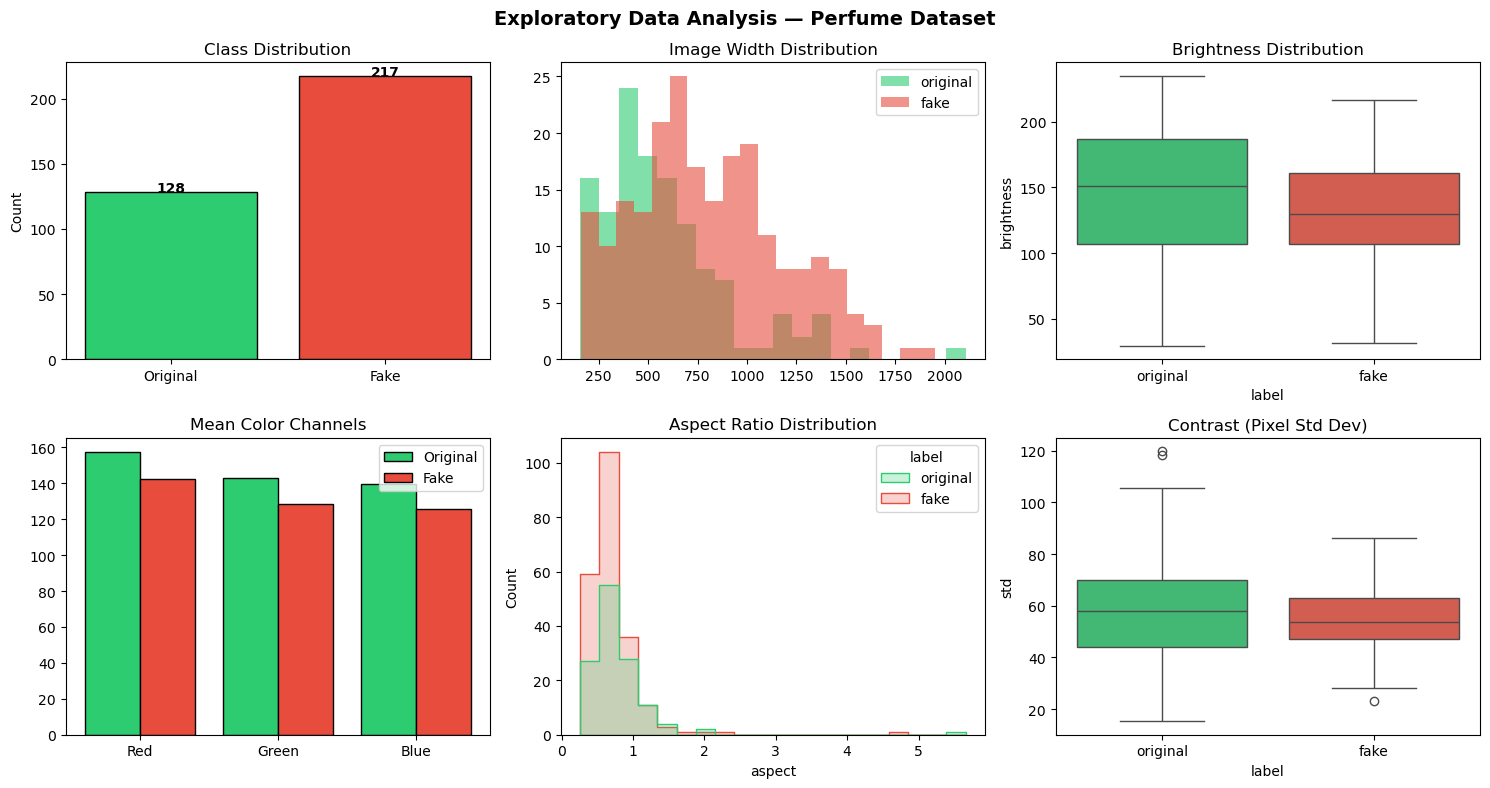

          brightness                   std                  width              \
                mean        std       mean        std        mean         std   
label                                                                           
fake      132.066142  39.091203  55.361226  12.165146  810.654378  380.257022   
original  146.670435  50.275641  58.946069  19.384272  584.718750  331.175785   

               height              
                 mean         std  
label                              
fake      1238.548387  552.408522  
original   787.726562  349.450383  


In [15]:
def image_stats(paths: list, label: str) -> pd.DataFrame:
    rows = []
    for p in paths:
        img = Image.open(p).convert('RGB')
        w, h = img.size
        arr = np.array(img)
        rows.append({
            'label': label,
            'width': w, 'height': h,
            'aspect': round(w/h, 2),
            'mean_r': arr[:,:,0].mean(),
            'mean_g': arr[:,:,1].mean(),
            'mean_b': arr[:,:,2].mean(),
            'brightness': arr.mean(),
            'std': arr.std(),
        })
    return pd.DataFrame(rows)

df_orig = image_stats(orig_files, 'original')
df_fake = image_stats(fake_files, 'fake')
df_all  = pd.concat([df_orig, df_fake], ignore_index=True)

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Exploratory Data Analysis — Perfume Dataset', fontsize=14, fontweight='bold')

palette = {'original': '#2ecc71', 'fake': '#e74c3c'}

# Class distribution
axes[0,0].bar(['Original', 'Fake'], [len(orig_files), len(fake_files)],
              color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate([len(orig_files), len(fake_files)]):
    axes[0,0].text(i, v+0.5, str(v), ha='center', fontweight='bold')

# Image width distribution
for label, color in palette.items():
    subset = df_all[df_all.label==label]
    axes[0,1].hist(subset['width'], bins=20, alpha=0.6, label=label, color=color)
axes[0,1].set_title('Image Width Distribution')
axes[0,1].legend()

# Brightness comparison
sns.boxplot(data=df_all, x='label', y='brightness', palette=palette, ax=axes[0,2])
axes[0,2].set_title('Brightness Distribution')

# Color channel means
channels = ['mean_r','mean_g','mean_b']
orig_means = df_orig[channels].mean()
fake_means = df_fake[channels].mean()
x = np.arange(3)
axes[1,0].bar(x-0.2, orig_means, 0.4, label='Original', color='#2ecc71', edgecolor='black')
axes[1,0].bar(x+0.2, fake_means, 0.4, label='Fake',     color='#e74c3c', edgecolor='black')
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(['Red','Green','Blue'])
axes[1,0].set_title('Mean Color Channels')
axes[1,0].legend()

# Aspect ratio
sns.histplot(data=df_all, x='aspect', hue='label', palette=palette,
             bins=20, ax=axes[1,1], element='step')
axes[1,1].set_title('Aspect Ratio Distribution')

# Contrast (std)
sns.boxplot(data=df_all, x='label', y='std', palette=palette, ax=axes[1,2])
axes[1,2].set_title('Contrast (Pixel Std Dev)')

plt.tight_layout()
plt.savefig(RESULT_DIR/'eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(df_all.groupby('label')[['brightness','std','width','height']].agg(['mean','std']))

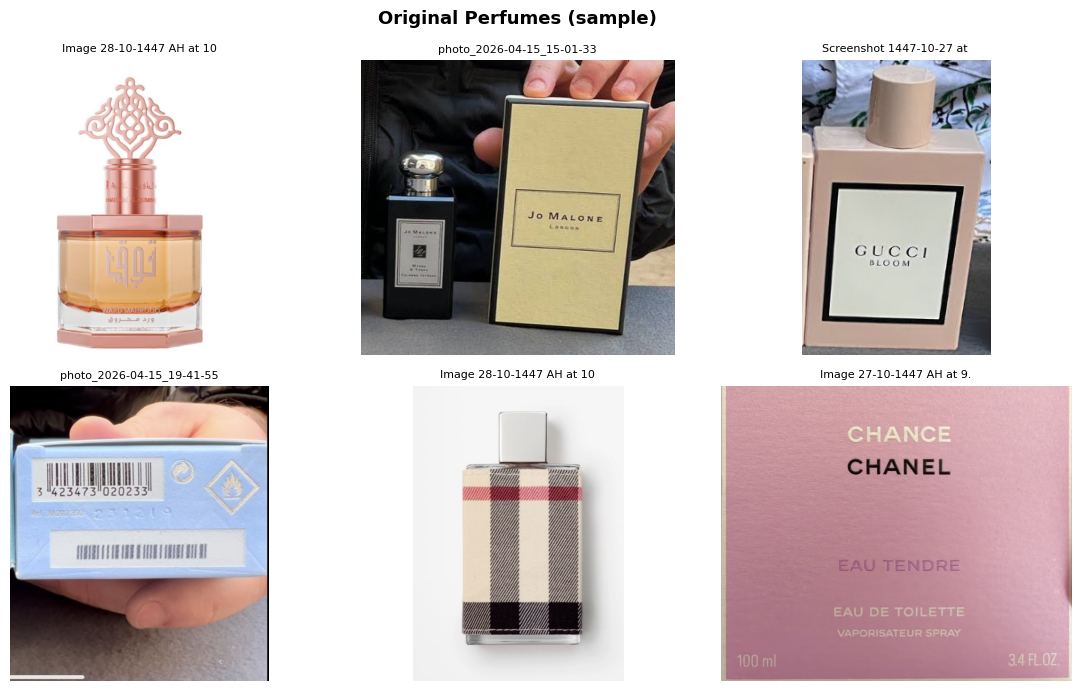

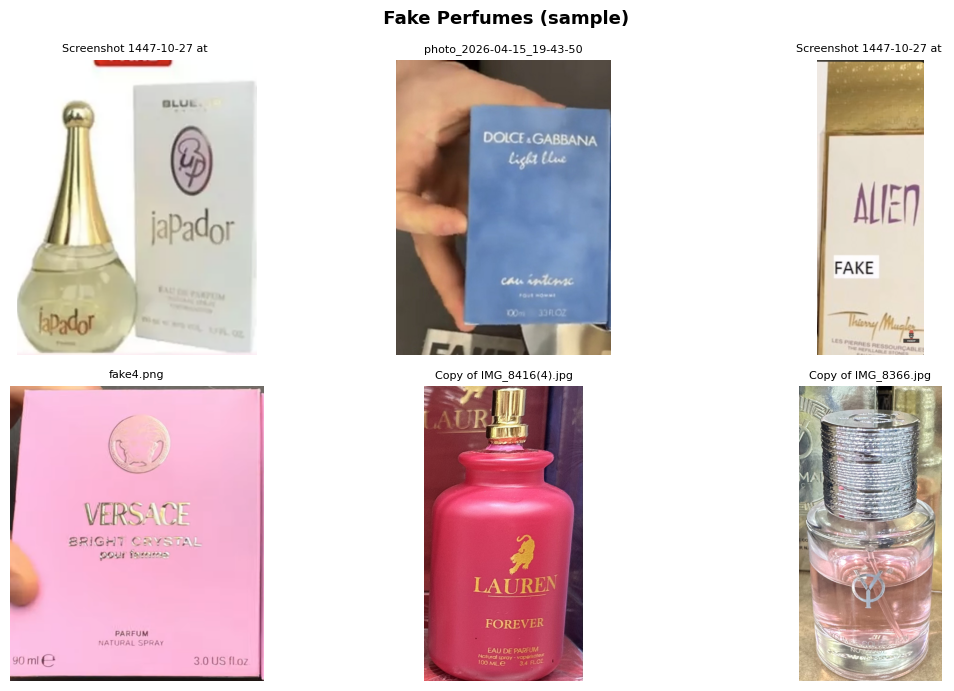

In [16]:
# ── Show sample images ────────────────────────────────────────────────────────
def show_grid(paths, title, n=6, cols=3):
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3.5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes = axes.flatten() if n > 1 else [axes]
    sample = random.sample(paths, min(n, len(paths)))
    for ax, p in zip(axes, sample):
        img = Image.open(p)
        ax.imshow(img)
        ax.set_title(p.name[:25], fontsize=8)
        ax.axis('off')
    for ax in axes[len(sample):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_grid(orig_files, 'Original Perfumes (sample)', n=6)
show_grid(fake_files, ' Fake Perfumes (sample)', n=6)

##  OCR Feature Extraction with PaddleOCR

Key textual fraud indicators:
- **Misspellings** in brand/product names
- **Bold/thick fonts** on fakes (colour of text, font weight)
- **Missing accents** or wrong characters
- **Different logo text** formatting

In [18]:
! pip install PaddleOCR

  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 7.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 MB 472.9 kB/s  0:00:54m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 733.8 kB/s  0:00:08 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 2.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 2.4 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 854.0/854.0 kB 2.5 MB/s  0:00:0036m-:--:--
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 2.7 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: PyYAML90m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/20 [shapely]
    Found existing installation: PyYAML 6.0.3━━━━━━━━━━━━━━━━━  3/20 [shapely]
    Uninstalling PyYAML-6.0.3:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/20 [shapely]
      Successfully uninstalled PyYAM

In [21]:
! pip install paddlepaddle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.5/104.5 MB 4.0 MB/s  0:00:26m0:00:0100:01
  Attempting uninstall: opt_einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [paddlepaddle] [paddlepaddle]


In [25]:
import os
from paddleocr import PaddleOCR
from tqdm import tqdm
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image

# 🔧 Fix Paddle warning
os.environ["PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK"] = "True"

# ✅ Correct initialization (removed show_log)
ocr_engine = PaddleOCR(
    use_angle_cls=True,
    lang='en'
)

AUTHENTIC_BRANDS = [
    'chanel','dior','gucci','versace','prada','armani','burberry',
    'givenchy','lancome','ysl','hermes','bvlgari','dolce','gabbana',
    'carolina','herrera','good','girl','boss','hugo','lacoste'
]

def extract_ocr_features(img_path: Path, engine) -> dict:
    try:
        result = engine.ocr(str(img_path), cls=True)

        if not result or not result[0]:
            return {
                'n_words': 0, 'avg_confidence': 0.0,
                'has_brand_keyword': 0, 'all_text': '',
                'text_density': 0.0, 'max_word_height': 0
            }

        lines = result[0]
        words, confs, heights = [], [], []

        for line in lines:
            box, (text, conf) = line
            words.append(text.lower())
            confs.append(conf)

            pts = np.array(box)
            h = abs(pts[0][1] - pts[2][1])
            heights.append(h)

        all_text = ' '.join(words)
        has_brand = int(any(b in all_text for b in AUTHENTIC_BRANDS))

        with Image.open(img_path) as img:
            img_area = (img.width * img.height) / 1000

        return {
            'n_words': len(words),
            'avg_confidence': float(np.mean(confs)) if confs else 0.0,
            'has_brand_keyword': has_brand,
            'all_text': all_text,
            'text_density': len(words) / max(img_area, 1),
            'max_word_height': float(max(heights)) if heights else 0.0
        }

    except Exception as e:
        print(f"OCR error on {img_path}: {e}")
        return {
            'n_words': 0, 'avg_confidence': 0.0,
            'has_brand_keyword': 0, 'all_text': '',
            'text_density': 0.0, 'max_word_height': 0
        }


# ==============================
# RUN OCR PIPELINE
# ==============================

print("Running OCR on all images...")

ocr_records = []

for path in tqdm(orig_files, desc='OCR — Original'):
    feats = extract_ocr_features(path, ocr_engine)
    feats.update({'path': str(path), 'label': 0})
    ocr_records.append(feats)

for path in tqdm(fake_files, desc='OCR — Fake'):
    feats = extract_ocr_features(path, ocr_engine)
    feats.update({'path': str(path), 'label': 1})
    ocr_records.append(feats)

df_ocr = pd.DataFrame(ocr_records)

df_ocr.to_csv(RESULT_DIR / 'ocr_features.csv', index=False)

print("\nOCR Feature Statistics by Class:")
print(df_ocr.groupby('label')[['n_words','avg_confidence','text_density','max_word_height']]
      .agg(['mean','std']).round(3))

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/ramahalharbi/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/ramahalharbi/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/ramahalharbi/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/ramahalharbi/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Use

Running OCR on all images...


OCR — Original: 100%|██████████| 128/128 [00:00<00:00, 177536.68it/s]


OCR error on original/Image 28-10-1447 AH at 9.51 am.jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on original/Image 27-10-1447 AH at 1.57 pm.jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on original/Image 27-10-1447 AH at 9.23 pm.jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on original/Image 27-10-1447 AH at 2.09 pm.jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on original/Image 28-10-1447 AH at 7.48 am (1).jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on original/Image 28-10-1447 AH at 8.10 am.jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on original/photo_2026-04-15_15-01-33.jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on original/Image 28-10-1447 AH at 7.53 am(1).jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on original/photo_2026-04-15_15-01-2

OCR — Fake: 100%|██████████| 217/217 [00:00<00:00, 181019.09it/s]

OCR error on fake/Copy of IMG_8364.jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on fake/Copy of IMG_8416.jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on fake/Copy of IMG_8370.jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on fake/Carolina Herreras Good Girl Blush (2).jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on fake/Copy of IMG_8417.jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on fake/Copy of IMG_8371.jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on fake/Copy of IMG_8365.jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on fake/Copy of IMG_8403.jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on fake/photo_2026-04-15_19-43-48.jpg: PaddleOCR.predict() got an unexpected keyword argument 'cls'
OCR error on fake/Copy of IMG_8434(1).jpg: PaddleOCR.predict(

[2026-04-16 13:58:07,381] [    INFO] category.py:224 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


ValueError: The palette dictionary is missing keys: {'0', '1'}

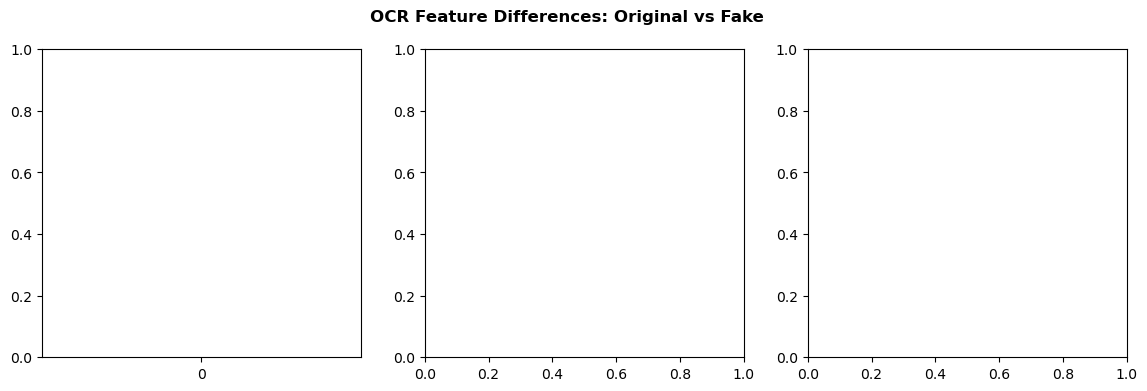

In [26]:
# Visualize OCR feature differences
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('OCR Feature Differences: Original vs Fake', fontweight='bold')

for ax, col in zip(axes, ['n_words', 'avg_confidence', 'max_word_height']):
    sns.boxplot(data=df_ocr, x='label', y=col, palette={0:'#2ecc71', 1:'#e74c3c'}, ax=ax)
    ax.set_xticklabels(['Original', 'Fake'])
    ax.set_title(col.replace('_',' ').title())

plt.tight_layout()
plt.savefig(RESULT_DIR/'ocr_analysis.png', dpi=150)
plt.show()

##  Step 6 — Train / Validation / Test Split

In [ ]:
# Build master dataframe
all_paths  = [(str(p), 0) for p in orig_files] + [(str(p), 1) for p in fake_files]
df_master  = pd.DataFrame(all_paths, columns=['path', 'label'])
df_master  = df_master.merge(
    df_ocr[['path','n_words','avg_confidence','text_density','max_word_height']],
    on='path', how='left'
).fillna(0)

OCR_FEATURE_COLS = ['n_words', 'avg_confidence', 'text_density', 'max_word_height']

# Stratified 70/15/15 split
X = df_master['path'].values
y = df_master['label'].values

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(splitter.split(X, y))

X_temp, y_temp = X[temp_idx], y[temp_idx]
splitter2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx_local, test_idx_local = next(splitter2.split(X_temp, y_temp))

df_train = df_master.iloc[train_idx].reset_index(drop=True)
df_val   = df_master.iloc[temp_idx[val_idx_local]].reset_index(drop=True)
df_test  = df_master.iloc[temp_idx[test_idx_local]].reset_index(drop=True)

print(f"Train: {len(df_train)}  (orig={sum(df_train.label==0)}, fake={sum(df_train.label==1)})")
print(f"Val:   {len(df_val)}  (orig={sum(df_val.label==0)}, fake={sum(df_val.label==1)})")
print(f"Test:  {len(df_test)}  (orig={sum(df_test.label==0)}, fake={sum(df_test.label==1)})")

df_master.to_csv(RESULT_DIR/'dataset_manifest.csv', index=False)

##  Step 7 — Advanced Augmentation Pipeline

Augmentations are designed specifically for perfume fraud cues:
- **Color jitter** — catches fakes with wrong hue cartoons
- **JPEG compression** — simulates phone photo quality
- **Gaussian blur** — blurry text is a fake indicator
- **Perspective transform** — bottle angles variation
- **Sharpen/Emboss** — logo texture changes

In [ ]:
IMG_SIZE = 384  # EfficientNet-B4 native size

train_transform = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE + 32),
    A.PadIfNeeded(IMG_SIZE + 32, IMG_SIZE + 32, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.RandomCrop(IMG_SIZE, IMG_SIZE),

    # ── Geometric ──────────────────────────────────────────────────────────
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.6),
    A.Perspective(scale=(0.02, 0.08), p=0.4),

    # ── Color — critical for detecting fake packaging colors ────────────────
    A.OneOf([
        A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.4, hue=0.1, p=1.0),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=40, val_shift_limit=20, p=1.0),
    ], p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ToGray(p=0.05),  # rare grayscale — forces shape focus

    # ── Texture & Sharpness — fake logos often have different sharpness ─────
    A.OneOf([
        A.Sharpen(alpha=(0.2, 0.5), lightness=(0.8, 1.2), p=1.0),
        A.Emboss(alpha=(0.2, 0.5), strength=(0.5, 1.0), p=1.0),
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.MotionBlur(blur_limit=5, p=1.0),
    ], p=0.4),

    # ── Noise ───────────────────────────────────────────────────────────────
    A.OneOf([
        A.GaussNoise(var_limit=(10, 50), p=1.0),
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=1.0),
    ], p=0.3),

    # ── JPEG compression — simulate phone camera quality ────────────────────
    A.ImageCompression(quality_lower=60, quality_upper=95, p=0.4),

    # ── Cutout / CoarseDropout — occlusion robustness ──────────────────────
    A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.3),

    # ── Normalize (ImageNet stats) ──────────────────────────────────────────
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(IMG_SIZE, IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

# ── Preview augmentations ─────────────────────────────────────────────────────
sample_img = cv2.imread(str(orig_files[0]))
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Augmentation Preview (Original Image × 10)', fontweight='bold')

preview_transform = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE + 32),
    A.PadIfNeeded(IMG_SIZE + 32, IMG_SIZE + 32, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.RandomCrop(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.7),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.4, hue=0.1, p=0.8),
    A.OneOf([
        A.Sharpen(p=1.0), A.GaussianBlur(blur_limit=5, p=1.0)
    ], p=0.5),
])

for ax in axes.flatten():
    aug = preview_transform(image=sample_img)['image']
    ax.imshow(aug)
    ax.axis('off')

plt.tight_layout()
plt.savefig(RESULT_DIR/'augmentation_preview.png', dpi=120)
plt.show()

## 📚 Step 8 — Dataset Class & DataLoaders

In [ ]:
class PerfumeDataset(Dataset):
    """
    Returns (image_tensor, ocr_feature_vector, label) tuples.
    """
    def __init__(self, df: pd.DataFrame, transform, ocr_cols: list):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.ocr_cols  = ocr_cols

        # Normalize OCR features
        self.ocr_means = df[ocr_cols].mean()
        self.ocr_stds  = df[ocr_cols].std().replace(0, 1)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = cv2.imread(row['path'])
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        aug  = self.transform(image=img)
        img_tensor = aug['image']   # float32 CHW

        ocr_vec = torch.tensor(
            ((row[self.ocr_cols] - self.ocr_means) / self.ocr_stds).values.astype(np.float32),
            dtype=torch.float32
        )

        label = torch.tensor(row['label'], dtype=torch.long)
        return img_tensor, ocr_vec, label


# ── Weighted sampler to handle class imbalance ────────────────────────────────
def make_weighted_sampler(df: pd.DataFrame):
    class_counts = Counter(df['label'])
    weights = [1.0 / class_counts[l] for l in df['label']]
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

BATCH_SIZE = 16
NUM_WORKERS = 0  # set to 4 if on Linux

train_ds = PerfumeDataset(df_train, train_transform, OCR_FEATURE_COLS)
val_ds   = PerfumeDataset(df_val,   val_transform,   OCR_FEATURE_COLS)
test_ds  = PerfumeDataset(df_test,  val_transform,   OCR_FEATURE_COLS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=make_weighted_sampler(df_train),
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"✅ DataLoaders ready")
print(f"   Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

## 🧠 Step 9 — Model Architecture

```
EfficientNet-B4 backbone (pretrained on ImageNet)
         │
   CNN features (1792-d)
         │
    FC(512) + GELU
         │
    Dropout(0.3)                 OCR features (4-d)
         │                            │
    CNN embed (256-d)           FC(32) + GELU
         └──────────┬───────────────┘
               Concat (288-d)
                    │
               FC(128) + GELU
                    │
                Dropout(0.2)
                    │
               FC(2) → logits
```

In [ ]:
class CounterfeitDetector(nn.Module):
    def __init__(self, backbone: str = 'efficientnet_b4',
                 ocr_dim: int = 4, num_classes: int = 2,
                 pretrained: bool = True):
        super().__init__()

        # ── CNN Backbone ───────────────────────────────────────────────────────
        self.backbone = timm.create_model(
            backbone, pretrained=pretrained, num_classes=0  # remove head
        )
        cnn_out = self.backbone.num_features  # 1792 for B4

        # ── Freeze all backbone layers initially ───────────────────────────────
        for param in self.backbone.parameters():
            param.requires_grad = False

        # ── CNN Projection Head ────────────────────────────────────────────────
        self.cnn_head = nn.Sequential(
            nn.Linear(cnn_out, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.GELU(),
        )

        # ── OCR Feature Head ───────────────────────────────────────────────────
        self.ocr_head = nn.Sequential(
            nn.Linear(ocr_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
        )

        # ── Fusion Classifier ──────────────────────────────────────────────────
        fusion_dim = 256 + 32
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, img: torch.Tensor, ocr_feat: torch.Tensor) -> torch.Tensor:
        cnn_feat  = self.backbone(img)         # (B, 1792)
        cnn_embed = self.cnn_head(cnn_feat)    # (B, 256)
        ocr_embed = self.ocr_head(ocr_feat)    # (B, 32)
        fused     = torch.cat([cnn_embed, ocr_embed], dim=1)  # (B, 288)
        return self.classifier(fused)           # (B, 2)

    def unfreeze_top_blocks(self, n_blocks: int = 2):
        """Progressive unfreezing: unfreeze last n blocks of backbone."""
        # EfficientNet blocks: blocks[0..n]
        all_blocks = list(self.backbone.blocks)
        for block in all_blocks[-n_blocks:]:
            for param in block.parameters():
                param.requires_grad = True
        # Always unfreeze BN and head
        for name, param in self.backbone.named_parameters():
            if 'bn' in name or 'norm' in name or 'head' in name:
                param.requires_grad = True
        print(f"  Unfrozen top {n_blocks} backbone blocks + BN layers")

    def unfreeze_all(self):
        for param in self.backbone.parameters():
            param.requires_grad = True
        print("  All backbone layers unfrozen")

    def count_trainable(self):
        total   = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  Total: {total:,} | Trainable: {trainable:,} ({100*trainable/total:.1f}%)")


model = CounterfeitDetector(backbone='efficientnet_b4',
                             ocr_dim=len(OCR_FEATURE_COLS),
                             pretrained=True).to(DEVICE)
model.count_trainable()

## 🏋️ Step 10 — Training with Progressive Unfreezing

**3-Phase strategy:**
- **Phase 1** (5 epochs): Freeze backbone → only train heads. High LR.
- **Phase 2** (5 epochs): Unfreeze top 3 blocks. Lower LR.
- **Phase 3** (10 epochs): Unfreeze all. Cosine LR decay.

In [ ]:
# ── Loss: Label Smoothing + Class Weights ─────────────────────────────────────
n0 = sum(df_train.label == 0)  # original count
n1 = sum(df_train.label == 1)  # fake count
class_weights = torch.tensor([n1/(n0+n1), n0/(n0+n1)], dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

print(f"Class weights → original: {class_weights[0]:.3f}, fake: {class_weights[1]:.3f}")


def get_trainable_params(model, backbone_lr_mult=0.1, base_lr=1e-3):
    """Differential learning rates: backbone gets lower LR."""
    backbone_params = [p for n,p in model.named_parameters()
                       if 'backbone' in n and p.requires_grad]
    head_params     = [p for n,p in model.named_parameters()
                       if 'backbone' not in n and p.requires_grad]
    return [
        {'params': backbone_params, 'lr': base_lr * backbone_lr_mult},
        {'params': head_params,     'lr': base_lr},
    ]


def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, ocr, labels in tqdm(loader, desc='  train', leave=False):
        imgs, ocr, labels = imgs.to(DEVICE), ocr.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
            logits = model(imgs, ocr)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        if scheduler is not None:
            scheduler.step()
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_probs, all_labels = [], []
    for imgs, ocr, labels in tqdm(loader, desc='  val ', leave=False):
        imgs, ocr, labels = imgs.to(DEVICE), ocr.to(DEVICE), labels.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
            logits = model(imgs, ocr)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        probs = F.softmax(logits, dim=1)[:,1].cpu().numpy()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return total_loss/total, correct/total, auc, all_probs, all_labels


# ── Training Loop ─────────────────────────────────────────────────────────────
PHASES = [
    # (epochs, unfreeze_call, base_lr, backbone_lr_mult, description)
    (5,  None,                                  1e-3, 0.0,  "Phase 1: Freeze backbone"),
    (5,  lambda m: m.unfreeze_top_blocks(3),    5e-4, 0.05, "Phase 2: Top-3 blocks"),
    (10, lambda m: m.unfreeze_all(),            1e-4, 0.1,  "Phase 3: Full fine-tune"),
]

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_auc':[]}
best_auc = 0.0
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))

for (n_epochs, unfreeze_fn, base_lr, bb_mult, phase_name) in PHASES:
    print(f"\n{'='*55}")
    print(f"🚀 {phase_name} ({n_epochs} epochs)")
    if unfreeze_fn:
        unfreeze_fn(model)
    model.count_trainable()

    param_groups = get_trainable_params(model, backbone_lr_mult=bb_mult, base_lr=base_lr)
    optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)
    total_steps = n_epochs * len(train_loader)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=[g['lr'] for g in param_groups],
        total_steps=total_steps, pct_start=0.1
    )

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, scaler)
        vl_loss, vl_acc, vl_auc, _, _ = eval_epoch(model, val_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['val_auc'].append(vl_auc)

        print(f"  Ep {epoch:02d}/{n_epochs} | "
              f"Loss {tr_loss:.4f}/{vl_loss:.4f} | "
              f"Acc {tr_acc:.3f}/{vl_acc:.3f} | "
              f"AUC {vl_auc:.4f}", end="")

        if vl_auc > best_auc:
            best_auc = vl_auc
            torch.save({'model_state': model.state_dict(),
                        'ocr_cols':    OCR_FEATURE_COLS,
                        'epoch':       epoch,
                        'auc':         vl_auc},
                       MODEL_DIR/'best_model.pth')
            print(" ✅ saved")
        else:
            print()

print(f"\n🏆 Best Validation AUC: {best_auc:.4f}")

## 📈 Step 11 — Training Curves

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Training History', fontweight='bold')

epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Train', color='#3498db')
axes[0].plot(epochs, history['val_loss'],   label='Val',   color='#e74c3c')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train', color='#3498db')
axes[1].plot(epochs, history['val_acc'],   label='Val',   color='#e74c3c')
axes[1].set_title('Accuracy'); axes[1].legend()

axes[2].plot(epochs, history['val_auc'], color='#9b59b6', label='Val AUC')
axes[2].axhline(best_auc, color='gray', linestyle='--', label=f'Best={best_auc:.3f}')
axes[2].set_title('Validation AUC'); axes[2].legend()

# Add phase separators
phase_ends = [PHASES[0][0], PHASES[0][0]+PHASES[1][0]]
for ax in axes:
    for end in phase_ends:
        ax.axvline(end, color='black', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(RESULT_DIR/'training_history.png', dpi=150)
plt.show()

## 🧪 Step 12 — Test Set Evaluation

In [ ]:
# Load best checkpoint
ckpt = torch.load(MODEL_DIR/'best_model.pth', map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded checkpoint from epoch {ckpt['epoch']} (AUC={ckpt['auc']:.4f})")

_, test_acc, test_auc, test_probs, test_labels = eval_epoch(model, test_loader, criterion)

test_preds = (np.array(test_probs) >= 0.5).astype(int)

print(f"\n📋 Test Results:")
print(f"  Accuracy : {test_acc:.4f}")
print(f"  AUC-ROC  : {test_auc:.4f}")
print(f"  Avg Prec : {average_precision_score(test_labels, test_probs):.4f}")
print()
print(classification_report(test_labels, test_preds,
                              target_names=['Original','Fake']))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Test Set Evaluation', fontweight='bold', fontsize=13)

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Original','Fake'],
            yticklabels=['Original','Fake'], ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {test_auc:.3f}')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(test_labels, test_probs)
ap = average_precision_score(test_labels, test_probs)
axes[2].plot(rec, prec, color='#3498db', lw=2, label=f'AP = {ap:.3f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULT_DIR/'test_evaluation.png', dpi=150)
plt.show()

## 🔥 Step 13 — Grad-CAM Explainability

Visualize WHAT the model looks at: logo region, text, bottle shape.

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Wrap model for GradCAM (it only needs image input)
class ImageOnlyWrapper(nn.Module):
    def __init__(self, full_model, ocr_zeros):
        super().__init__()
        self.full_model = full_model
        self.ocr_zeros  = ocr_zeros
    def forward(self, x):
        b = x.shape[0]
        ocr = self.ocr_zeros.expand(b, -1).to(x.device)
        return self.full_model(x, ocr)

ocr_zeros = torch.zeros(1, len(OCR_FEATURE_COLS))
wrapped   = ImageOnlyWrapper(model, ocr_zeros).eval().to(DEVICE)

# Target layer: last conv block of EfficientNet
target_layer = model.backbone.blocks[-1]
cam = GradCAM(model=wrapped, target_layers=[target_layer])

def visualize_gradcam(paths: list, labels: list, title: str, n: int = 6):
    cols = 3
    rows = n // cols
    fig, axes = plt.subplots(rows, cols*2, figsize=(cols*5, rows*3.5))
    fig.suptitle(title, fontweight='bold')
    axes = axes.reshape(rows, cols*2)

    idxs = random.sample(range(len(paths)), min(n, len(paths)))
    for i, idx in enumerate(idxs):
        row, col = i // cols, i % cols
        p = paths[idx]
        label = labels[idx]

        # Load and preprocess
        orig_img = cv2.imread(str(p))
        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
        h_orig, w_orig = orig_img.shape[:2]

        input_tensor = preprocess_image(
            cv2.resize(orig_img, (IMG_SIZE, IMG_SIZE)),
            mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]
        ).to(DEVICE)

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(label)]
        )[0]

        rgb_img = cv2.resize(orig_img, (IMG_SIZE, IMG_SIZE)) / 255.0
        cam_img = show_cam_on_image(rgb_img.astype(np.float32), grayscale_cam, use_rgb=True)

        axes[row, col*2].imshow(orig_img)
        axes[row, col*2].set_title(f"{'Original' if label==0 else 'Fake'}", fontsize=9)
        axes[row, col*2].axis('off')

        axes[row, col*2+1].imshow(cam_img)
        axes[row, col*2+1].set_title("Grad-CAM", fontsize=9)
        axes[row, col*2+1].axis('off')

    plt.tight_layout()
    plt.savefig(RESULT_DIR/f'gradcam_{title[:10]}.png', dpi=120)
    plt.show()

# Sample from test set
test_orig_paths = [Path(r.path) for _, r in df_test[df_test.label==0].iterrows()]
test_fake_paths = [Path(r.path) for _, r in df_test[df_test.label==1].iterrows()]

visualize_gradcam(test_orig_paths, [0]*len(test_orig_paths), 'Original Perfumes', n=6)
visualize_gradcam(test_fake_paths, [1]*len(test_fake_paths), 'Fake Perfumes', n=6)

## 🔍 Step 14 — OCR Contribution Analysis

In [ ]:
# Ablation: compare model WITH vs WITHOUT OCR features
@torch.no_grad()
def eval_no_ocr(model, loader, criterion):
    """Evaluate model but zero-out OCR features to measure OCR contribution."""
    model.eval()
    all_probs, all_labels = [], []
    for imgs, ocr, labels in tqdm(loader, desc='  no-OCR eval', leave=False):
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        ocr_zero = torch.zeros_like(ocr).to(DEVICE)  # zero out OCR
        with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
            logits = model(imgs, ocr_zero)
        probs = F.softmax(logits, dim=1)[:,1].cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return auc, all_probs, all_labels

auc_with_ocr, probs_with, labels_test2  = test_auc, test_probs, test_labels
auc_no_ocr,   probs_without, _          = eval_no_ocr(model, test_loader, criterion)

print(f"\n🧪 OCR Ablation Study:")
print(f"  AUC with OCR    : {auc_with_ocr:.4f}")
print(f"  AUC without OCR : {auc_no_ocr:.4f}")
print(f"  OCR contribution: +{auc_with_ocr - auc_no_ocr:.4f}")

# ROC comparison
fig, ax = plt.subplots(figsize=(7, 5))
fpr1, tpr1, _ = roc_curve(labels_test2, probs_with)
fpr2, tpr2, _ = roc_curve(labels_test2, probs_without)
ax.plot(fpr1, tpr1, color='#e74c3c', lw=2, label=f'With OCR (AUC={auc_with_ocr:.3f})')
ax.plot(fpr2, tpr2, color='#3498db', lw=2, linestyle='--', label=f'Vision Only (AUC={auc_no_ocr:.3f})')
ax.plot([0,1],[0,1],'k--',alpha=0.3)
ax.set_title('OCR Feature Contribution — ROC Comparison', fontweight='bold')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR/'ocr_ablation.png', dpi=150)
plt.show()

## 🔮 Step 15 — Inference on New Images

In [ ]:
def predict_image(image_path: str | Path, model, ocr_engine, 
                  ocr_means, ocr_stds, threshold: float = 0.5) -> dict:
    """
    Full pipeline inference on a single image.
    Returns dict with label, confidence, OCR text, and fraud indicators.
    """
    image_path = Path(image_path)
    model.eval()

    # ── Image preprocessing ────────────────────────────────────────────────────
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    aug = val_transform(image=img)
    img_tensor = aug['image'].unsqueeze(0).to(DEVICE)

    # ── OCR ────────────────────────────────────────────────────────────────────
    ocr_feats = extract_ocr_features(image_path, ocr_engine)
    ocr_raw   = pd.Series({c: ocr_feats[c] for c in OCR_FEATURE_COLS})
    ocr_norm  = ((ocr_raw - ocr_means) / ocr_stds).values.astype(np.float32)
    ocr_tensor = torch.tensor(ocr_norm).unsqueeze(0).to(DEVICE)

    # ── Inference ──────────────────────────────────────────────────────────────
    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
            logits = model(img_tensor, ocr_tensor)
        probs = F.softmax(logits, dim=1)[0].cpu().numpy()

    fake_prob = float(probs[1])
    is_fake   = fake_prob >= threshold

    # ── Fraud indicators ───────────────────────────────────────────────────────
    indicators = []
    if ocr_feats['avg_confidence'] < 0.7 and ocr_feats['n_words'] > 0:
        indicators.append('⚠️  Low OCR confidence (blurry/irregular text)')
    if ocr_feats['max_word_height'] > 80:
        indicators.append('⚠️  Oversized text (bold font on packaging)')
    if not ocr_feats['has_brand_keyword']:
        indicators.append('⚠️  No recognized brand keyword detected')

    return {
        'path':        str(image_path),
        'prediction':  'FAKE' if is_fake else 'ORIGINAL',
        'fake_prob':   round(fake_prob * 100, 1),
        'ocr_text':    ocr_feats['all_text'][:200],
        'indicators':  indicators,
    }

# Compute OCR stats from training set
ocr_means_train = df_train[OCR_FEATURE_COLS].mean()
ocr_stds_train  = df_train[OCR_FEATURE_COLS].std().replace(0, 1)

# ── Demo on a few test images ─────────────────────────────────────────────────
demo_imgs = (random.sample(test_orig_paths[:5], min(2, len(test_orig_paths))) +
             random.sample(test_fake_paths[:5], min(2, len(test_fake_paths))))

print("🔍 Demo Predictions:\n")
for p in demo_imgs:
    result = predict_image(p, model, ocr_engine, ocr_means_train, ocr_stds_train)
    color = '🔴' if result['prediction'] == 'FAKE' else '🟢'
    print(f"{color} {Path(result['path']).name}")
    print(f"   Prediction: {result['prediction']} (Fake prob: {result['fake_prob']}%)")
    print(f"   OCR text  : {result['ocr_text'][:80]}")
    for ind in result['indicators']:
        print(f"   {ind}")
    print()

## 💾 Step 16 — Save Full Inference Pipeline

In [ ]:
import json

# Save config
config = {
    'img_size':      IMG_SIZE,
    'backbone':      'efficientnet_b4',
    'ocr_cols':      OCR_FEATURE_COLS,
    'ocr_means':     ocr_means_train.to_dict(),
    'ocr_stds':      ocr_stds_train.to_dict(),
    'threshold':     0.5,
    'imagenet_mean': [0.485, 0.456, 0.406],
    'imagenet_std':  [0.229, 0.224, 0.225],
    'test_auc':      round(test_auc, 4),
    'test_acc':      round(test_acc, 4),
}

with open(MODEL_DIR/'inference_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✅ Saved:")
print(f"   {MODEL_DIR/'best_model.pth'}  — model weights")
print(f"   {MODEL_DIR/'inference_config.json'}  — inference config")
print(f"   {RESULT_DIR}/  — all visualizations and CSV")
print()
print("📦 To load for inference later:")
print("""
import json, torch
with open('models/inference_config.json') as f:
    cfg = json.load(f)
model = CounterfeitDetector('efficientnet_b4', len(cfg['ocr_cols'])).to(DEVICE)
ckpt = torch.load('models/best_model.pth', map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
""")

## 📋 Summary

| Component | Choice | Rationale |
|-----------|--------|-----------|
| Backbone | EfficientNet-B4 | Best accuracy/params, 384px native |
| OCR | PaddleOCR | Fast, accurate, Arabic+English |
| Augmentation | Albumentations | Color jitter, blur, perspective for perfume cues |
| Class imbalance | WeightedSampler + Label Smoothing | 128 orig vs 346 fake |
| Training | Progressive unfreezing × 3 phases | Avoids catastrophic forgetting |
| Explainability | Grad-CAM | Shows logo/text regions |
| OCR Fusion | Feature concat after CNN head | Adds text fraud signals |

**Key fraud indicators the model learns:**
- 🎨 Wrong color saturation in cartoon/box artwork
- 🔤 Bold, oversized or blurry text on label
- 🏷️ Missing or misspelled brand name
- 📐 Slightly different bottle shape proportions
- 🖼️ Logo position/size inconsistencies